# Preprocessing and Data Augmentation

1. dataset checking
2. preprocess
3. augmentation

In [3]:
!pip -q install torch torchvision torchaudio

In [13]:
import os
import glob
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Dataset checking

In [14]:
data_dir = "/kaggle/input/datasets/fardinabdullaacanto"
mask_dir = "/kaggle/input/datasets/gprem09/seg-lungs-luna16/seg-lungs-LUNA16"

all_files = sorted(glob.glob(os.path.join(data_dir, "**/*.mhd"), recursive=True))

scans = []
for p in all_files:
    if "seg-lungs-LUNA16" not in p:
        scans.append(p)

In [15]:
print(len(scans))
print(scans[0])

267
/kaggle/input/datasets/fardinabdullaacanto/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.mhd


In [16]:
def load_img(path):
    img = sitk.ReadImage(path)
    arr = sitk.GetArrayFromImage(img)
    return arr.astype(np.float32)

In [17]:
def get_mask(scan_p, m_dir):
    fname = os.path.basename(scan_p)
    res = glob.glob(os.path.join(m_dir, "**", fname), recursive=True)
    if len(res) > 0:
        return load_img(res[0])
    return np.zeros_like(load_img(scan_p))

In [18]:
test_path = scans[0]
raw_vol = load_img(test_path)
true_mask = get_mask(test_path, mask_dir)

In [19]:
print(raw_vol.shape)

(121, 512, 512)


# 2. Preprocess

In [20]:
def apply_mask(vol, m, bg=-1000.0):
    masked = np.copy(vol)
    masked[m == 0] = bg
    return masked

In [21]:
def resize_data(vol, shape=(64, 128, 128), is_mask=False):
    curr = vol.shape
    f = [shape[0]/curr[0], shape[1]/curr[1], shape[2]/curr[2]]
    o = 0 if is_mask else 1
    return zoom(vol, f, order=o)

In [22]:
def norm_data(vol, mn=-1000, mx=400):
    c = np.clip(vol, mn, mx)
    n = (c - mn) / (mx - mn)
    return n

In [23]:
lungs = apply_mask(raw_vol, true_mask)
lungs_res = resize_data(lungs)
preped = norm_data(lungs_res)

In [24]:
print(preped.shape)
print(preped.min(), preped.max())

(64, 128, 128)
0.0 1.0


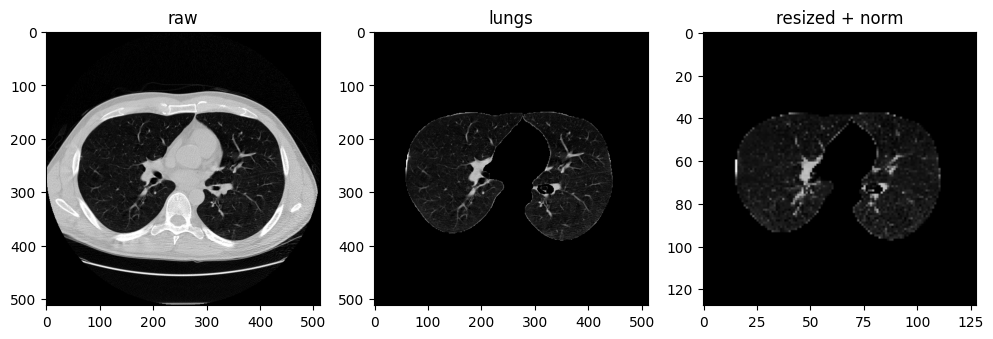

In [25]:
z = raw_vol.shape[0] // 2
z2 = preped.shape[0] // 2

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(raw_vol[z], cmap='gray', vmin=-1000, vmax=400)
ax[0].set_title("raw")
ax[1].imshow(lungs[z], cmap='gray', vmin=-1000, vmax=400)
ax[1].set_title("lungs")
ax[2].imshow(preped[z2], cmap='gray', vmin=0, vmax=1)
ax[2].set_title("resized + norm")
plt.show()

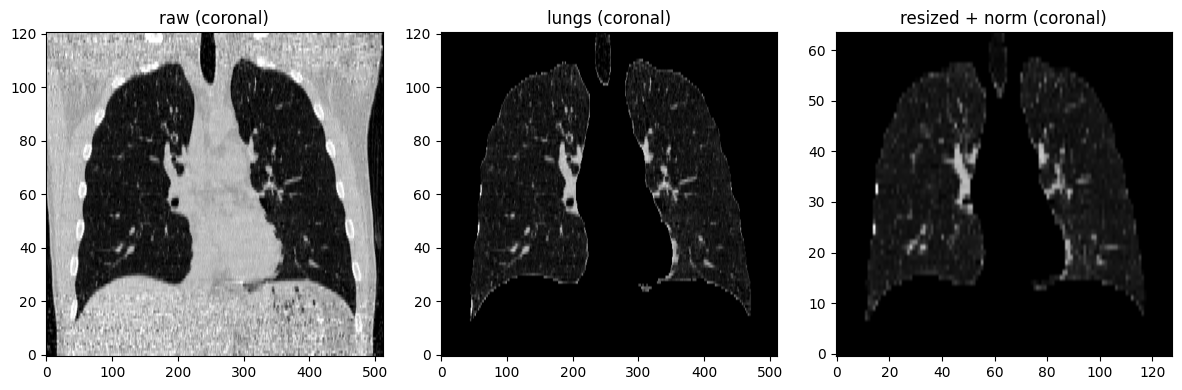

In [33]:
c1 = raw_vol.shape[1] // 2
c2 = preped.shape[1] // 2

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(raw_vol[:, c1, :], cmap='gray', origin='lower', aspect='auto', vmin=-1000, vmax=400)
ax[0].set_title("raw (coronal)")
ax[1].imshow(lungs[:, c1, :], cmap='gray', origin='lower', aspect='auto', vmin=-1000, vmax=400)
ax[1].set_title("lungs (coronal)")
ax[2].imshow(preped[:, c2, :], cmap='gray', origin='lower', aspect='auto', vmin=0, vmax=1)
ax[2].set_title("resized + norm (coronal)")
plt.tight_layout()
plt.show()

# 3. Augmentation

In [26]:
def make_missing(preped_vol, res_mask, ratio=(0.15, 0.35)):
    d, h, w = preped_vol.shape
    corrupt = np.copy(preped_vol)
    y = np.zeros_like(preped_vol, dtype=np.float32)
    
    r = np.random.uniform(ratio[0], ratio[1])
    n_remove = int(d * r)
    top = np.random.rand() > 0.5
    
    if top:
        slc = slice(0, n_remove)
    else:
        slc = slice(d - n_remove, d)
        
    y[slc] = res_mask[slc]
    corrupt[slc] = 0.0
    return corrupt, y

In [27]:
mask_res = resize_data(true_mask, is_mask=True)
x, y = make_missing(preped, mask_res)

In [28]:
print(x.shape, y.shape)

(64, 128, 128) (64, 128, 128)


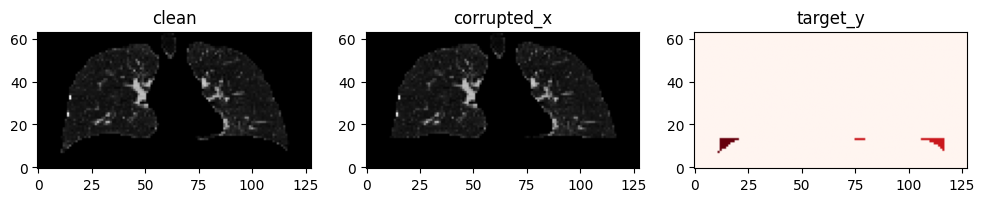

In [29]:
c = x.shape[1] // 2
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(preped[:, c, :], cmap='gray', origin='lower')
ax[0].set_title("clean")
ax[1].imshow(x[:, c, :], cmap='gray', origin='lower')
ax[1].set_title("corrupted_x")
ax[2].imshow(y[:, c, :], cmap='Reds', origin='lower')
ax[2].set_title("target_y")
plt.show()

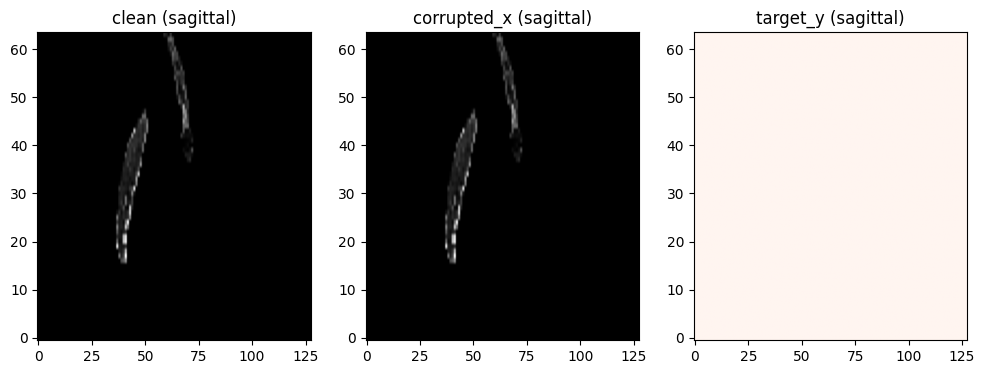

In [35]:
s = x.shape[2] // 2
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(preped[:, :, s], cmap='gray', origin='lower', aspect='auto')
ax[0].set_title("clean (sagittal)")
ax[1].imshow(x[:, :, s], cmap='gray', origin='lower', aspect='auto')
ax[1].set_title("corrupted_x (sagittal)")
ax[2].imshow(y[:, :, s], cmap='Reds', origin='lower', aspect='auto')
ax[2].set_title("target_y (sagittal)")
plt.show()

# 4. Dataloader

In [30]:
class CTDataset(Dataset):
    def __init__(self, paths, mdir, shape=(64, 128, 128)):
        self.p = paths
        self.m = mdir
        self.s = shape

    def __len__(self):
        return len(self.p)

    def __getitem__(self, idx):
        raw = load_img(self.p[idx])
        mask = get_mask(self.p[idx], self.m)
        
        l = apply_mask(raw, mask)
        l_res = resize_data(l, self.s)
        p = norm_data(l_res)
        
        m_res = resize_data(mask, self.s, is_mask=True)
        x, y = make_missing(p, m_res)
            
        t_x = torch.tensor(x).unsqueeze(0)
        t_y = torch.tensor(y).unsqueeze(0)
        return t_x, t_y

In [31]:
ds = CTDataset(scans[:4], mask_dir)
dl = DataLoader(ds, batch_size=2, shuffle=True)

In [32]:
bx, by = next(iter(dl))
print(bx.shape, by.shape)

torch.Size([2, 1, 64, 128, 128]) torch.Size([2, 1, 64, 128, 128])
